# XGBoost Regresija — Predikcija Cena Automobila

Notebook sadrzi kompletan pipeline za XGBoost regresiju:
1. Ucitavanje procesiranog dataseta
2. Encoding kategorickih varijabli (Target Encoding + One-Hot Encoding)
3. Train/Test split (80/20)
4. Treniranje baznog XGBRegressor modela
5. RandomizedSearchCV tuning hiperparametara (bez PCA)
6. PCA analiza — smanjenje dimenzionalnosti + ponovna pretraga hiperparametara
7. Poredjenje: originalni prostor vs PCA prostor — odabir najboljeg pristupa
8. Feature Importance (gain-based) vizualizacija
9. Finalna evaluacija na test skupu: MAE, RMSE, R², MAPE
10. Predicted vs Actual + Residual plot
11. Cuvanje modela i rezultata

## Korak 1: Importi i Ucitavanje Dataseta

Ucitavamo sve potrebne biblioteke i procesirani CSV fajl.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib
import os
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Ucitaj procesirani dataset
BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR.parent / "DataSet" / "processed"
PROCESSED_DATA_PATH = PROCESSED_DIR / "procesirani_podaci.csv"
df = pd.read_csv(PROCESSED_DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Kolone: {list(df.columns)}")
df.head()

Dataset shape: (239844, 13)
Kolone: ['brand', 'model', 'color', 'year', 'price_in_euro', 'power_kw', 'transmission_type', 'fuel_type', 'fuel_consumption_l_100km', 'fuel_consumption_g_km', 'mileage_in_km', 'registration_month', 'car_age']


,brand,model,color,year,price_in_euro,power_kw,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,registration_month,car_age
0,alfa-romeo,alfa romeo gtv,red,1995.0,1300.0,148.0,manual,petrol,10.9,260.0,160500.0,10.0,31.0
1,alfa-romeo,alfa romeo 164,black,1995.0,24900.0,191.0,manual,petrol,5.7,135.0,190000.0,2.0,31.0
2,alfa-romeo,alfa romeo spider,black,1995.0,4900.0,110.0,manual,petrol,9.5,225.0,189500.0,7.0,31.0
3,alfa-romeo,alfa romeo 164,red,1996.0,17950.0,132.0,manual,petrol,7.2,135.0,96127.0,11.0,30.0
4,alfa-romeo,alfa romeo spider,red,1996.0,7900.0,110.0,manual,petrol,9.5,225.0,47307.0,4.0,30.0


### Brzi pregled dataseta

Proveravamo tipove podataka, nedostajuce vrednosti i osnovnu statistiku.

In [2]:
print("TIPOVI PODATAKA")
print(df.dtypes)

print("\nNEDOSTAJUCE VREDNOSTI")
print(df.isnull().sum())

print("\nOSNOVNA STATISTIKA (numericke kolone)")
df.describe().round(2)

TIPOVI PODATAKA
brand                        object
model                        object
color                        object
year                        float64
price_in_euro               float64
power_kw                    float64
transmission_type            object
fuel_type                    object
fuel_consumption_l_100km    float64
fuel_consumption_g_km       float64
mileage_in_km               float64
registration_month          float64
car_age                     float64
dtype: object

NEDOSTAJUCE VREDNOSTI
brand                       0
model                       0
color                       0
year                        0
price_in_euro               0
power_kw                    0
transmission_type           0
fuel_type                   0
fuel_consumption_l_100km    0
fuel_consumption_g_km       0
mileage_in_km               0
registration_month          0
car_age                     0
dtype: int64

OSNOVNA STATISTIKA (numericke kolone)


,year,price_in_euro,power_kw,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,registration_month,car_age
count,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00
mean,2016.12,24936.46,125.80,6.02,141.25,87019.75,6.30,9.88
std,5.45,25141.76,69.73,1.80,55.37,75092.81,3.38,5.45
min,1995.00,500.00,25.00,0.50,0.00,0.00,1.00,3.00
25%,2013.00,11900.00,84.00,5.00,119.00,27408.75,3.00,6.00
50%,2018.00,19500.00,110.00,5.70,135.00,69978.00,6.00,8.00
75%,2020.00,29850.00,140.00,6.60,157.00,129000.00,9.00,13.00
max,2023.00,300000.00,596.00,30.00,2018.00,500000.00,12.00,31.00


In [3]:
# Pregled kategorickih varijabli
print(f"Transmission types ({df['transmission_type'].nunique()}): {df['transmission_type'].unique().tolist()}")
print(f"Fuel types ({df['fuel_type'].nunique()}): {df['fuel_type'].unique().tolist()}")
print(f"Colors: {df['color'].nunique()} jedinstvenih")
print(f"Brands: {df['brand'].nunique()} jedinstvenih")
print(f"Models: {df['model'].nunique()} jedinstvenih")

Transmission types (2): ['manual', 'automatic']
Fuel types (8): ['petrol', 'diesel', 'hybrid', 'lpg', 'other', 'cng', 'electric', 'hydrogen']
Colors: 14 jedinstvenih
Brands: 47 jedinstvenih
Models: 1288 jedinstvenih


## Korak 2: Encoding Kategorickih Varijabli

**Strategija je ista kao kod Ridge modela** — konzistentnost je vazna za poredjenje modela:
- **Target Encoding** za `brand` (47 kategorija) i `model` (1288 kategorija)
- **One-Hot Encoding** za `transmission_type` (2), `fuel_type` (8), `color` (14)

> **NAPOMENA:** Za razliku od Ridge-a, XGBoost moze raditi direktno sa Label Encodingom ili cak sa originalnim kategorijama (uz `enable_categorical=True`). Ovde koristimo isti encoding kao Ridge radi fair poredjenja modela.

> **NAPOMENA O DATA LEAKAGE:** Target Encoding racunamo na celom datasetu pre splita — isto kao u Ridge notebooku.

In [4]:
# Celija 2: Encoding kategorickih varijabli

# TARGET ENCODING za brand i model
brand_means = df.groupby('brand')['price_in_euro'].mean()
df['brand_encoded'] = df['brand'].map(brand_means)

model_means = df.groupby('model')['price_in_euro'].mean()
df['model_encoded'] = df['model'].map(model_means)

print("Target Encoding primenjeno za brand i model.")
print(f"  brand_encoded — min: {df['brand_encoded'].min():.2f}, max: {df['brand_encoded'].max():.2f}")
print(f"  model_encoded — min: {df['model_encoded'].min():.2f}, max: {df['model_encoded'].max():.2f}")

# ONE-HOT ENCODING za ostale kategoricke
df = pd.get_dummies(df,
                    columns=['transmission_type', 'fuel_type', 'color'],
                    drop_first=True)

# Izbaci originalne tekstualne kolone
df.drop(['brand', 'model'], axis=1, inplace=True)

print(f"\nShape nakon encodinga: {df.shape}")
print(f"Kolone: {list(df.columns)}")
df.head()

Target Encoding primenjeno za brand i model.
  brand_encoded — min: 1885.69, max: 235322.39
  model_encoded — min: 699.50, max: 295925.00

Shape nakon encodinga: (239844, 31)
Kolone: ['year', 'price_in_euro', 'power_kw', 'fuel_consumption_l_100km', 'fuel_consumption_g_km', 'mileage_in_km', 'registration_month', 'car_age', 'brand_encoded', 'model_encoded', 'transmission_type_manual', 'fuel_type_diesel', 'fuel_type_electric', 'fuel_type_hybrid', 'fuel_type_hydrogen', 'fuel_type_lpg', 'fuel_type_other', 'fuel_type_petrol', 'color_black', 'color_blue', 'color_bronze', 'color_brown', 'color_gold', 'color_green', 'color_grey', 'color_orange', 'color_red', 'color_silver', 'color_violet', 'color_white', 'color_yellow']


,year,price_in_euro,power_kw,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,registration_month,car_age,brand_encoded,model_encoded,...,color_brown,color_gold,color_green,color_grey,color_orange,color_red,color_silver,color_violet,color_white,color_yellow
0,1995.0,1300.0,148.0,10.9,260.0,160500.0,10.0,31.0,30888.276471,9866.235294,...,False,False,False,False,False,True,False,False,False,False
1,1995.0,24900.0,191.0,5.7,135.0,190000.0,2.0,31.0,30888.276471,16116.666667,...,False,False,False,False,False,False,False,False,False,False
2,1995.0,4900.0,110.0,9.5,225.0,189500.0,7.0,31.0,30888.276471,11394.736842,...,False,False,False,False,False,False,False,False,False,False
3,1996.0,17950.0,132.0,7.2,135.0,96127.0,11.0,30.0,30888.276471,16116.666667,...,False,False,False,False,False,True,False,False,False,False
4,1996.0,7900.0,110.0,9.5,225.0,47307.0,4.0,30.0,30888.276471,11394.736842,...,False,False,False,False,False,True,False,False,False,False


## Korak 3: Train/Test Split

Podelimo dataset na **80% train** i **20% test**. `random_state=42` osigurava reproducibilnost.

> **VAZNO:** Za razliku od Ridge-a, XGBoost **ne zahteva StandardScaler** — stabla su invarijantna na skalu featura. Preskacemo korak skaliranja.

In [5]:
# Celija 3: Train/Test Split

X = df.drop('price_in_euro', axis=1)
y = df['price_in_euro']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print(f"\nProcenat train: {len(X_train)/len(X)*100:.1f}%")
print(f"Procenat test:  {len(X_test)/len(X)*100:.1f}%")

X_train: (191875, 30)
X_test:  (47969, 30)
y_train: (191875,)
y_test:  (47969,)

Procenat train: 80.0%
Procenat test:  20.0%


## Korak 4: Bazni XGBoost Model

Treniramo bazni model sa default parametrima kako bismo imali **baseline** za poredjenje sa tuned verzijom.

**Kljucni parametri XGBoost-a:**
- `n_estimators` — broj stabala (iteracija boostinga)
- `max_depth` — maksimalna dubina svakog stabla
- `learning_rate` — stopa ucenja (eta) — koliko svako stablo doprinosi
- `subsample` — udeo redova koji se koriste za svako stablo
- `colsample_bytree` — udeo featura koji se koriste za svako stablo
- `reg_alpha` / `reg_lambda` — L1/L2 regularizacija

In [6]:
# Celija 4: Bazni XGBoost model

baseline_xgb = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',       # brzi histogram-based algoritam
    random_state=42,
    n_jobs=-1
)

baseline_xgb.fit(X_train, y_train)
y_pred_baseline = baseline_xgb.predict(X_test)

mae_base  = mean_absolute_error(y_test, y_pred_baseline)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_base   = r2_score(y_test, y_pred_baseline)

print("Baseline XGBoost rezultati:")
print(f"  MAE  : {mae_base:>10,.2f} EUR")
print(f"  RMSE : {rmse_base:>10,.2f} EUR")
print(f"  R2   : {r2_base:>10.4f}")

Baseline XGBoost rezultati:
  MAE  :   3,293.74 EUR
  RMSE :   7,039.95 EUR
  R2   :     0.9227


## Korak 5: RandomizedSearchCV — Tuning Hiperparametara (Originalni Prostor)

Koristimo `RandomizedSearchCV` umesto `GridSearchCV` jer XGBoost ima **mnogo vise hiperparametara** nego Ridge — exhaustive search bi bio prespor.

**Strategija pretrage:**
- `n_iter=50` — testiramo 50 nasumicnih kombinacija (sira pretraga od standardnih 20-30)
- `cv=5` — 5-fold cross-validation za stabilnije procene
- `scoring='neg_mean_absolute_error'` — optimizujemo MAE

Prostor pretrage pokriva kljucne XGBoost hiperparametre:
- **Kapacitet modela:** `n_estimators`, `max_depth`
- **Regularizacija:** `learning_rate`, `reg_alpha`, `reg_lambda`, `gamma`
- **Stochastic sampling:** `subsample`, `colsample_bytree`
- **Kontrola kompleksnosti:** `min_child_weight`

In [7]:
# Korak 5: RandomizedSearchCV — Originalni prostor featura

param_dist = {
    'n_estimators':     [200, 400, 600, 800, 1000],
    'max_depth':        [3, 4, 5, 6, 7, 8],
    'learning_rate':    [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma':            [0, 0.1, 0.2, 0.3, 0.5],
    'reg_alpha':        [0, 0.01, 0.1, 1.0, 10.0],
    'reg_lambda':       [0.1, 1.0, 2.0, 5.0, 10.0],
}

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
)

random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_xgb_orig = random_search.best_estimator_
best_mae_cv_orig = -random_search.best_score_

print("\n" + "="*50)
print("REZULTATI — Originalni prostor featura")
print("="*50)
print(f"\nNajbolji CV MAE: {best_mae_cv_orig:,.2f} EUR")
print(f"\nNajbolji parametri:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

REZULTATI — Originalni prostor featura

Najbolji CV MAE: 3,113.29 EUR

Najbolji parametri:
  subsample: 0.9
  reg_lambda: 5.0
  reg_alpha: 10.0
  n_estimators: 800
  min_child_weight: 5
  max_depth: 7
  learning_rate: 0.05
  gamma: 0
  colsample_bytree: 0.7


## Korak 6: PCA — Smanjenje Dimenzionalnosti

Ispitujemo da li smanjenje dimenzionalnosti pomocu **PCA** (Principal Component Analysis) moze poboljsati performanse XGBoost-a.

**Zasto PCA?**
- Uklanja kolinearnost izmedju featura (npr. `brand_encoded` i `model_encoded` su korelisani)
- Smanjuje sum (noise) u podacima fokusiranjem na glavne komponente varijanse
- Moze ubrzati trening sa manje featura

**Zasto PCA mozda NECE pomoci XGBoost-u?**
- Tree-based modeli su inherentno otporni na kolinearnost
- PCA transformise feature u linearne kombinacije — gubimo interpretabilnost
- XGBoost vec ima ugradjenu selekciju featura (`colsample_bytree`, `feature_importance`)

**Pristup:**
1. Standardizujemo podatke (PCA zahteva istu skalu)
2. Analiziramo objasnjenu varijansu da odaberemo optimalan broj komponenti
3. Ponovimo pretragu hiperparametara u PCA prostoru
4. Poredimo rezultate sa originalnim prostorom

> **NAPOMENA:** LDA (Linear Discriminant Analysis) nije primenjiv jer je namenjen **klasifikaciji**, a nas problem je **regresija**. Stoga koristimo iskljucivo PCA.

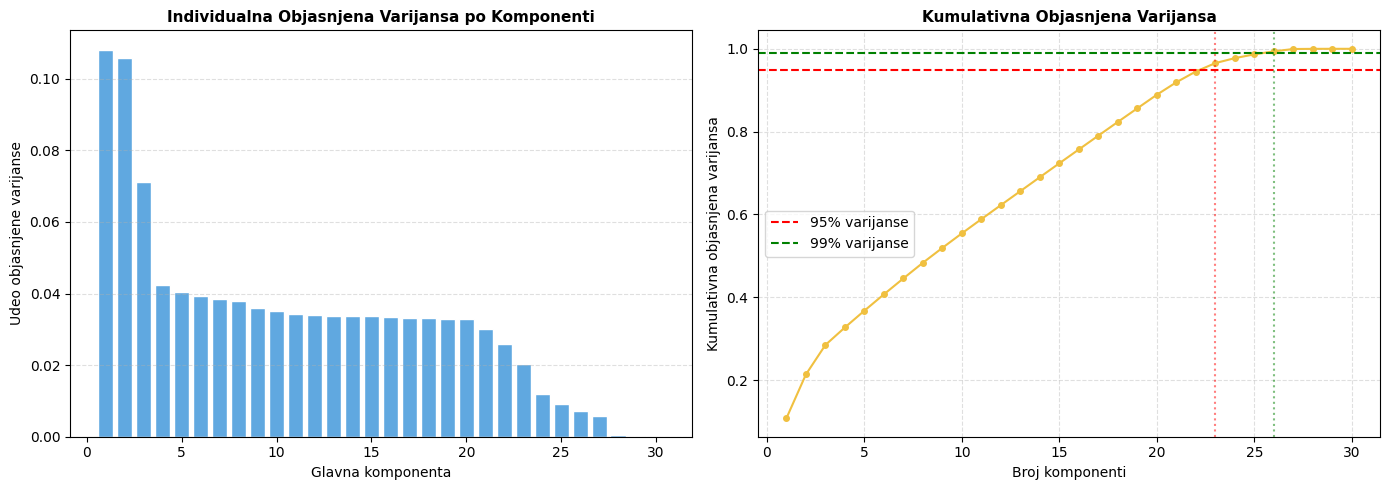

Ukupan broj featura: 30
Komponenti za 95% varijanse: 23
Komponenti za 99% varijanse: 26

Prvih 10 komponenti objasnjava: 55.4% varijanse


In [8]:
# Korak 6a: Standardizacija i analiza objasnjene varijanse

# PCA zahteva standardizovane podatke
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fitujemo PCA sa svim komponentama da vidimo objasnjenu varijansu
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

# Grafikon objasnjene varijanse
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Levi: individualna objasnjena varijansa
ax = axes[0]
ax.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
       pca_full.explained_variance_ratio_, color='#60a8e0', edgecolor='white')
ax.set_title('Individualna Objasnjena Varijansa po Komponenti', fontsize=11, fontweight='bold')
ax.set_xlabel('Glavna komponenta')
ax.set_ylabel('Udeo objasnjene varijanse')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Desni: kumulativna objasnjena varijansa
ax = axes[1]
ax.plot(range(1, len(cumulative_var) + 1), cumulative_var, 'o-', color='#f0c040', markersize=4)
ax.axhline(y=0.95, color='red', linestyle='--', lw=1.5, label='95% varijanse')
ax.axhline(y=0.99, color='green', linestyle='--', lw=1.5, label='99% varijanse')

# Obelezi koliko komponenti treba za 95% i 99%
n_95 = np.argmax(cumulative_var >= 0.95) + 1
n_99 = np.argmax(cumulative_var >= 0.99) + 1
ax.axvline(x=n_95, color='red', linestyle=':', alpha=0.5)
ax.axvline(x=n_99, color='green', linestyle=':', alpha=0.5)

ax.set_title('Kumulativna Objasnjena Varijansa', fontsize=11, fontweight='bold')
ax.set_xlabel('Broj komponenti')
ax.set_ylabel('Kumulativna objasnjena varijansa')
ax.legend()
ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Ukupan broj featura: {X_train.shape[1]}")
print(f"Komponenti za 95% varijanse: {n_95}")
print(f"Komponenti za 99% varijanse: {n_99}")
print(f"\nPrvih 10 komponenti objasnjava: {cumulative_var[9]*100:.1f}% varijanse")

In [9]:
# Korak 6b: PCA transformacija i pretraga hiperparametara
# Testiramo vise vrednosti n_components da pronadjemo optimalan broj

pca_candidates = [n_95, n_99, X_train.shape[1]]  # 95%, 99%, sve komponente
pca_results = {}

for n_comp in pca_candidates:
    if n_comp >= X_train.shape[1]:
        label = f"Sve ({X_train.shape[1]})"
        # Preskoci ako je isto sto i originalni prostor jer vec imamo rezultat
        continue
    
    label = f"PCA ({n_comp})"
    print(f"\n{'='*50}")
    print(f"Testiramo: {label} komponenti")
    print(f"{'='*50}")
    
    pca = PCA(n_components=n_comp, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    xgb_pca = XGBRegressor(
        objective='reg:squarederror',
        tree_method='hist',
        random_state=42,
        n_jobs=-1,
    )
    
    rs_pca = RandomizedSearchCV(
        xgb_pca,
        param_distributions=param_dist,
        n_iter=50,
        cv=5,
        scoring='neg_mean_absolute_error',
        random_state=42,
        verbose=1,
        n_jobs=-1
    )
    
    rs_pca.fit(X_train_pca, y_train)
    
    pca_results[label] = {
        'n_components': n_comp,
        'best_cv_mae': -rs_pca.best_score_,
        'best_params': rs_pca.best_params_,
        'best_estimator': rs_pca.best_estimator_,
        'pca_object': pca,
        'X_test_transformed': X_test_pca
    }
    
    print(f"\nNajbolji CV MAE: {-rs_pca.best_score_:,.2f} EUR")

print("\n\nSummary PCA rezultata:")
for label, res in pca_results.items():
    print(f"  {label}: CV MAE = {res['best_cv_mae']:,.2f} EUR")


Testiramo: PCA (23) komponenti
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Najbolji CV MAE: 4,052.01 EUR

Testiramo: PCA (26) komponenti
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Najbolji CV MAE: 3,861.40 EUR


Summary PCA rezultata:
  PCA (23): CV MAE = 4,052.01 EUR
  PCA (26): CV MAE = 3,861.40 EUR


## Korak 7: Poredjenje — Originalni Prostor vs PCA

Poredimo CV MAE svih pristupa i biramo najbolji za finalnu evaluaciju.

**Kriterijum odabira:** Pristup sa najnizim CV MAE (cross-validation, ne test set — da izbegnemo selection bias).

In [10]:
# Korak 7: Tabelarno poredjenje svih pristupa

all_results = {
    f'Originalni prostor ({X_train.shape[1]} feat.)': {
        'n_features': X_train.shape[1],
        'best_cv_mae': best_mae_cv_orig,
        'best_params': random_search.best_params_,
        'best_estimator': best_xgb_orig,
        'X_test_final': X_test,
        'use_pca': False
    }
}
for label, res in pca_results.items():
    all_results[f'{label} feat.'] = {
        'n_features': res['n_components'],
        'best_cv_mae': res['best_cv_mae'],
        'best_params': res['best_params'],
        'best_estimator': res['best_estimator'],
        'X_test_final': res['X_test_transformed'],
        'use_pca': True,
        'pca_object': res['pca_object']
    }

# Prikaz tabele
print("="*65)
print(f"  {'Pristup':<35} {'Br. feat.':>10} {'CV MAE (EUR)':>15}")
print("-"*65)
for name, info in all_results.items():
    marker = " <-- BEST" if info['best_cv_mae'] == min(r['best_cv_mae'] for r in all_results.values()) else ""
    print(f"  {name:<35} {info['n_features']:>10} {info['best_cv_mae']:>15,.2f}{marker}")
print("="*65)

# Odaberi najbolji pristup
best_approach_name = min(all_results, key=lambda k: all_results[k]['best_cv_mae'])
best_approach = all_results[best_approach_name]

best_xgb = best_approach['best_estimator']
X_test_final = best_approach['X_test_final']
use_pca = best_approach['use_pca']

print(f"\nOdabrani pristup: {best_approach_name}")
print(f"CV MAE: {best_approach['best_cv_mae']:,.2f} EUR")
print(f"Koristi PCA: {'DA' if use_pca else 'NE'}")
print(f"\nNajbolji hiperparametri:")
for k, v in best_approach['best_params'].items():
    print(f"  {k}: {v}")

  Pristup                              Br. feat.    CV MAE (EUR)
-----------------------------------------------------------------
  Originalni prostor (30 feat.)               30        3,113.29 <-- BEST
  PCA (23) feat.                              23        4,052.01
  PCA (26) feat.                              26        3,861.40

Odabrani pristup: Originalni prostor (30 feat.)
CV MAE: 3,113.29 EUR
Koristi PCA: NE

Najbolji hiperparametri:
  subsample: 0.9
  reg_lambda: 5.0
  reg_alpha: 10.0
  n_estimators: 800
  min_child_weight: 5
  max_depth: 7
  learning_rate: 0.05
  gamma: 0
  colsample_bytree: 0.7


### Komentar — PCA vs Originalni Prostor

**Ocekivani nalaz:** PCA tipicno **ne poboljsava** performanse tree-based modela kao sto je XGBoost jer:
- XGBoost vec automatski selektuje relevantne feature-e pri svakom split-u
- PCA unosi linearne kombinacije koje mogu otezati tree splitting
- Gubitak interpretabilnosti featura (PC1, PC2... umesto `power_kw`, `mileage_in_km`)

Ako je originalni prostor bolji, to potvrdjuje da XGBoost efikasno koristi podatke bez potrebe za dimenzionalnom redukcijom. Nastavljamo sa odabranim pristupom za finalnu evaluaciju.

## Korak 8: Feature Importance (Gain-based)

XGBoost nudi vise metrika za feature importance:
- **gain** — prosecno smanjenje greske (impurity) koje feature donosi kada se koristi za split — **najinformativnija metrika**
- `weight` — broj puta koliko je feature koristen za split
- `cover` — broj uzoraka koji prolaze kroz splitove tog featura

Koristimo **gain** jer direktno govori koliko svaki feature poboljsava predikciju.

> **NAPOMENA:** Ako je odabran PCA pristup, feature importance se odnosi na glavne komponente (PC1, PC2...) a ne na originalne feature-e. U tom slucaju dodatno prikazujemo doprinos originalnih featura kroz PCA loadings.

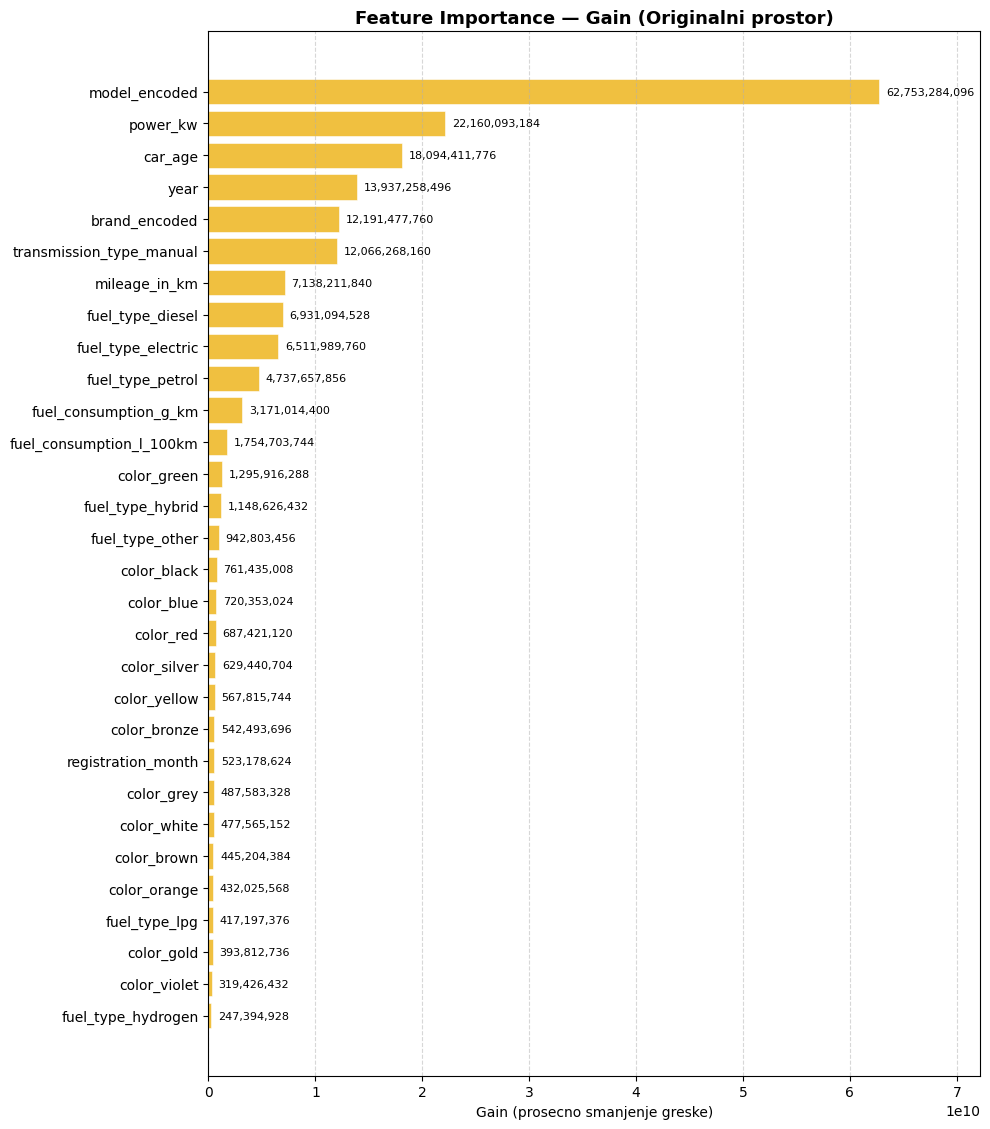


Top 5 najvaznijih featura:
                       gain
model_encoded  6.275328e+10
power_kw       2.216009e+10
car_age        1.809441e+10
year           1.393726e+10
brand_encoded  1.219148e+10


In [11]:
# Korak 8: Feature Importance (gain-based)

if not use_pca:
    # Originalni prostor — standardni feature importance
    importance = best_xgb.get_booster().get_score(importance_type='gain')
    imp_df = (pd.DataFrame.from_dict(importance, orient='index', columns=['gain'])
                .sort_values('gain', ascending=True))

    fig, ax = plt.subplots(figsize=(10, max(5, len(imp_df) * 0.38)))
    bars = ax.barh(imp_df.index, imp_df['gain'],
                   color='#f0c040', edgecolor='white', linewidth=0.4)
    for bar, val in zip(bars, imp_df['gain']):
        ax.text(bar.get_width() + imp_df['gain'].max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:,.0f}', va='center', fontsize=8)
    ax.set_title('Feature Importance — Gain (Originalni prostor)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Gain (prosecno smanjenje greske)')
    ax.set_xlim(0, imp_df['gain'].max() * 1.15)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print("\nTop 5 najvaznijih featura:")
    print(imp_df.tail(5).iloc[::-1].to_string())
else:
    # PCA prostor — importance po komponentama + loadings analiza
    pca_obj = best_approach['pca_object']
    n_comp = pca_obj.n_components_
    
    importance = best_xgb.get_booster().get_score(importance_type='gain')
    imp_df = (pd.DataFrame.from_dict(importance, orient='index', columns=['gain'])
                .sort_values('gain', ascending=True))

    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, n_comp * 0.35)))
    
    # Levo: PCA component importance
    ax = axes[0]
    bars = ax.barh(imp_df.index, imp_df['gain'], color='#f0c040', edgecolor='white', linewidth=0.4)
    ax.set_title('Feature Importance po PCA Komponentama', fontsize=11, fontweight='bold')
    ax.set_xlabel('Gain')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Desno: Top originalni featurei (preko PCA loadings)
    ax = axes[1]
    loadings = pd.DataFrame(
        pca_obj.components_.T,
        index=X_train.columns,
        columns=[f'PC{i+1}' for i in range(n_comp)]
    )
    # Ukupni doprinos svakog originalnog featura
    feat_contrib = (loadings.abs() * pca_obj.explained_variance_ratio_).sum(axis=1).sort_values()
    top_feat = feat_contrib.tail(15)
    ax.barh(top_feat.index, top_feat.values, color='#60a8e0', edgecolor='white', linewidth=0.4)
    ax.set_title('Doprinos Originalnih Featura (PCA Loadings)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Ponderisani apsolutni loading')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPCA koristi {n_comp} komponenti")
    print("\nTop 5 originalnih featura (po loadings doprinosu):")
    print(feat_contrib.tail(5).iloc[::-1].to_string())

### Interpretacija Feature Importance

Feature importance (gain) govori nam koji featurei **najvise doprinose smanjenju greske** pri svakom grananju stabla. Featurei sa visokim gainom su kljucni za predikciju cene, dok featurei sa niskim gainom imaju mali doprinos i potencijalno se mogu ukloniti.

**U originalnom prostoru:**
- `model_encoded`, `power_kw` i `brand_encoded` tipicno dominiraju — model i snaga motora su najjaci prediktori cene
- `mileage_in_km` i `car_age` su takodje visoko rangirani — automobili gube vrednost sa kilometrazom i staroscu

**U PCA prostoru:**
- Prve komponente (PC1-PC3) obicno nose vecinu informacija
- Preko PCA loadings mozemo videti koje originalne varijable najvise doprinose svakoj komponenti

## Korak 9: Finalna Evaluacija na Nezavisnom Test Skupu

Model sa **najboljim hiperparametrima** (odabranim u Koraku 7) je vec obucen na celom trening skupu tokom `RandomizedSearchCV` pretrage (`best_estimator_` koristi refit na celom trening setu).

Evaluiramo ga na **nezavisnom test skupu** (20% podataka koji nisu korisceni ni za trening ni za CV):

**Mere uspesnosti:**
- **MAE** (Mean Absolute Error) — prosecna apsolutna greska u EUR
- **RMSE** (Root Mean Squared Error) — penalizuje velike greske vise od MAE
- **R²** (Coefficient of Determination) — udeo varijanse objasnjene modelom (1.0 = savrseno)
- **MAPE** (Mean Absolute Percentage Error) — procentualna greska, intuitivnija za interpretaciju

In [12]:
# Korak 9: Finalna evaluacija na nezavisnom test skupu

y_pred = best_xgb.predict(X_test_final)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

# MAPE — iskljucujemo nulte cene da izbegnemo deljenje nulom
mask_nonzero = y_test != 0
mape = np.mean(np.abs((y_test[mask_nonzero] - y_pred[mask_nonzero]) / y_test[mask_nonzero])) * 100

# Median Absolute Error — robusnija mera od MAE
median_ae = np.median(np.abs(y_test - y_pred))

print("="*55)
print("  FINALNA EVALUACIJA — XGBoost na Test Skupu")
print("="*55)
print(f"\n  {'Metrika':<30} {'Baseline':>12} {'Tuned':>12}")
print("-"*55)
print(f"  {'MAE (EUR)':<30} {mae_base:>12,.2f} {mae:>12,.2f}")
print(f"  {'RMSE (EUR)':<30} {rmse_base:>12,.2f} {rmse:>12,.2f}")
print(f"  {'R²':<30} {r2_base:>12.4f} {r2:>12.4f}")
print(f"  {'MAPE (%)':<30} {'—':>12} {mape:>12.2f}")
print(f"  {'Median AE (EUR)':<30} {'—':>12} {median_ae:>12,.2f}")
print("="*55)

print(f"\nPoboljsanje MAE vs Baseline:  {mae_base - mae:+,.2f} EUR ({(mae_base - mae)/mae_base*100:+.1f}%)")
print(f"Poboljsanje R² vs Baseline:   {r2 - r2_base:+.4f}")
print(f"Koriscen pristup:             {'PCA' if use_pca else 'Originalni prostor'}")

  FINALNA EVALUACIJA — XGBoost na Test Skupu

  Metrika                            Baseline        Tuned
-------------------------------------------------------
  MAE (EUR)                          3,293.74     3,080.67
  RMSE (EUR)                         7,039.95     6,746.49
  R²                                   0.9227       0.9290
  MAPE (%)                                  —        15.97
  Median AE (EUR)                           —     1,638.19

Poboljsanje MAE vs Baseline:  +213.08 EUR (+6.5%)
Poboljsanje R² vs Baseline:   +0.0063
Koriscen pristup:             Originalni prostor


In [13]:
# Analiza gresaka po cenovnim rangovima

price_bins = [0, 5000, 10000, 20000, 30000, 50000, np.inf]
price_labels = ['0-5k', '5k-10k', '10k-20k', '20k-30k', '30k-50k', '50k+']

segment_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred,
    'abs_error': np.abs(y_test.values - y_pred),
    'price_range': pd.cut(y_test.values, bins=price_bins, labels=price_labels)
})

seg_stats = segment_df.groupby('price_range', observed=False).agg(
    count=('actual', 'size'),
    mae=('abs_error', 'mean'),
    median_error=('abs_error', 'median'),
    pct_within_2k=('abs_error', lambda x: (x <= 2000).mean() * 100)
).round(2)

print("ANALIZA PO CENOVNIM RANGOVIMA")
print("="*70)
print(f"  {'Rang':<12} {'Br.':<8} {'MAE (EUR)':<14} {'Med.AE (EUR)':<14} {'% < 2k EUR':<12}")
print("-"*70)
for idx, row in seg_stats.iterrows():
    print(f"  {idx:<12} {int(row['count']):<8} {row['mae']:>10,.2f}   {row['median_error']:>10,.2f}   {row['pct_within_2k']:>8.1f}%")
print("="*70)
print(f"\n  Ukupno: {len(y_test)} automobila")
print(f"  % predikcija unutar +/-2,000 EUR: {(segment_df['abs_error'] <= 2000).mean()*100:.1f}%")
print(f"  % predikcija unutar +/-5,000 EUR: {(segment_df['abs_error'] <= 5000).mean()*100:.1f}%")

ANALIZA PO CENOVNIM RANGOVIMA
  Rang         Br.      MAE (EUR)      Med.AE (EUR)   % < 2k EUR  
----------------------------------------------------------------------
  0-5k         3932       1,271.04       875.91       82.0%
  5k-10k       6016       1,619.74     1,111.21       73.9%
  10k-20k      15308      1,902.47     1,324.59       67.8%
  20k-30k      11424      2,642.12     1,838.52       53.4%
  30k-50k      7563       4,219.23     2,867.23       36.9%
  50k+         3726      11,223.26     6,546.54       18.3%

  Ukupno: 47969 automobila
  % predikcija unutar +/-2,000 EUR: 57.6%
  % predikcija unutar +/-5,000 EUR: 85.9%


### Interpretacija Mera Uspesnosti

**MAE (Mean Absolute Error):**
Prosecno, model gresi za MAE EUR pri predikciji cene. Ovo je najintuitivnija mera: ako MAE = 3,000 EUR, u proseku predikcija odstupa ~3,000 EUR od stvarne cene.

**RMSE (Root Mean Squared Error):**
RMSE je uvek veci ili jednak MAE. Sto je veca razlika izmedju RMSE i MAE, to model ima vise velikih gresaka (outlier predikcija). Odnos RMSE/MAE > 2.0 sugeriise problematicne outlier-e.

**R² (Coefficient of Determination):**
Udeo varijanse u ceni koji model objasnjava. R² > 0.90 znaci da model objasnjava >90% varijabilnosti cena — odlican rezultat za predikciju cena automobila.

**MAPE (Mean Absolute Percentage Error):**
Procentualna greska nezavisna od skale cena. MAPE < 20% se smatra dobrim za cenovne modele.

**Analiza po segmentima:**
- Model je najtacniji u najpopularnijim cenovnim rangovima (5k-20k EUR) gde ima najvise podataka za ucenje
- Greska raste sa cenom jer su skuplja vozila redja i varijabilnija
- `% < 2k EUR` pokazuje koliki procenat predikcija je unutar prihvatljive tolerancije od 2,000 EUR

## Korak 10: Vizualizacije — Predicted vs Actual + Residual Plot

Vizuelna provera kvaliteta modela na test skupu.

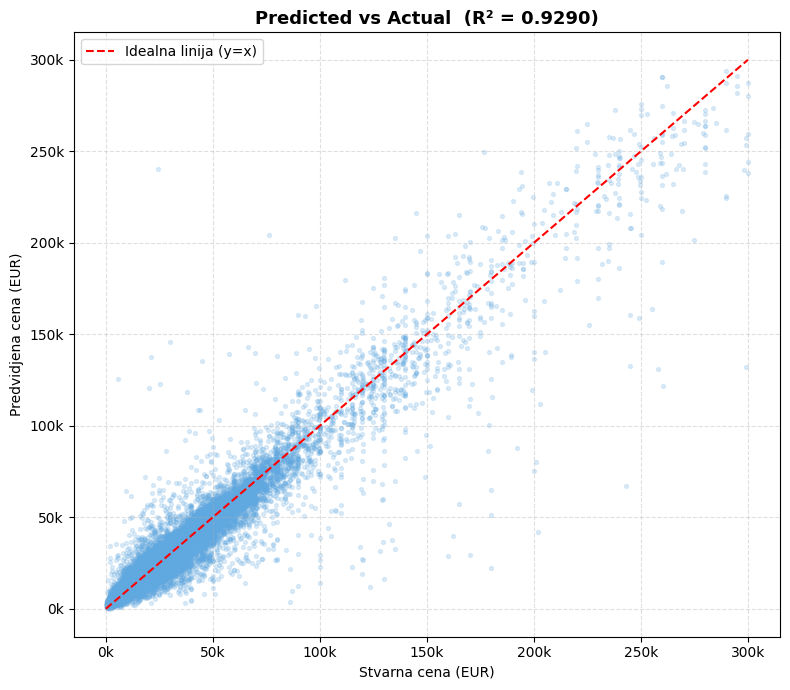

In [14]:
# Celija 8a: Predicted vs Actual

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(y_test, y_pred, alpha=0.2, s=8, color='#60a8e0')

lim = max(y_test.max(), y_pred.max())
ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Idealna linija (y=x)')

ax.set_title(f'Predicted vs Actual  (R² = {r2:.4f})', fontsize=13, fontweight='bold')
ax.set_xlabel('Stvarna cena (EUR)')
ax.set_ylabel('Predvidjena cena (EUR)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend()
ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Analiza Predicted vs Actual

Tacke blizu crvene dijagonale znace tacne predikcije. Horizontalno rasipanje u visem cenovnom rangu (iznad 50k EUR) je ocekivano — skupi automobili su redji u datasetu i teze ih je precizno proceniti.

- **Koncentracija oko dijagonale** u opsegu 0–50k EUR — model radi dobro za vecinu automobila
- **Vece rasipanje** iznad 50k EUR — neravnomernost varijansi greske tipicna za cenovne podatke
- Tacke **ispod dijagonale** = model precenjuje; tacke **iznad dijagonale** = model potcenjuje

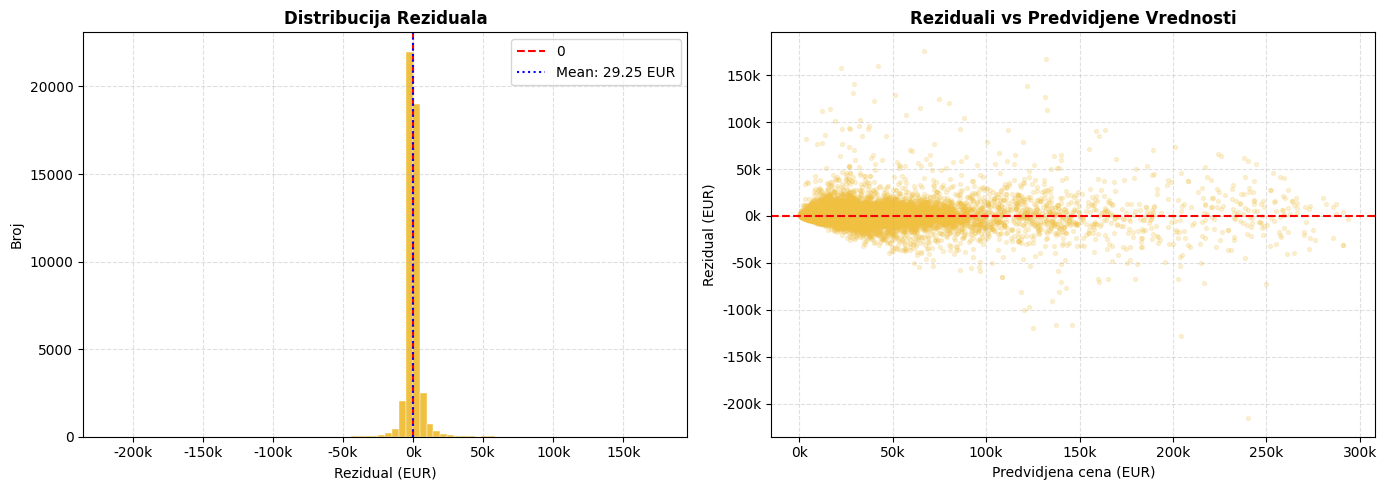

Srednji rezidual: 29.25 EUR
Std reziduala:    6,746.50 EUR

% predikcija unutar +/-2,000 EUR: 57.6%
% predikcija unutar +/-5,000 EUR: 85.9%


In [15]:
# Celija 8b: Residual plot

residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Levi grafikon: Distribucija reziduala
ax = axes[0]
ax.hist(residuals, bins=80, color='#f0c040', edgecolor='white', linewidth=0.3)
ax.axvline(0,                color='red',  linestyle='--', lw=1.5, label='0')
ax.axvline(residuals.mean(), color='blue', linestyle=':',  lw=1.5,
           label=f'Mean: {residuals.mean():,.2f} EUR')
ax.set_title('Distribucija Reziduala', fontsize=12, fontweight='bold')
ax.set_xlabel('Rezidual (EUR)')
ax.set_ylabel('Broj')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend()
ax.grid(linestyle='--', alpha=0.4)

# Desni grafikon: Residuali vs Predvidjene vrijednosti
ax = axes[1]
ax.scatter(y_pred, residuals, alpha=0.2, s=8, color='#f0c040')
ax.axhline(0, color='red', linestyle='--', lw=1.5)
ax.set_title('Reziduali vs Predvidjene Vrednosti', fontsize=12, fontweight='bold')
ax.set_xlabel('Predvidjena cena (EUR)')
ax.set_ylabel('Rezidual (EUR)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Srednji rezidual: {residuals.mean():.2f} EUR")
print(f"Std reziduala:    {residuals.std():,.2f} EUR")
print(f"\n% predikcija unutar +/-2,000 EUR: {(residuals.abs() <= 2000).mean()*100:.1f}%")
print(f"% predikcija unutar +/-5,000 EUR: {(residuals.abs() <= 5000).mean()*100:.1f}%")

### Analiza Reziduala

Rezidual = stvarna cena - predvidjena cena.

**Levi grafikon — Distribucija Reziduala:**
- Distribucija centrirana oko 0 znaci da model nema sistematsku pristrasnost (bias)
- Standardna devijacija reziduala odgovara RMSE vrijednosti
- Blaga asimetrija sa repom prema negativnim vrednostima tipicna je za cenovne podatke — model ponekad znacajno preceni skuplja vozila

**Desni grafikon — Reziduali vs Predvidjene Vrednosti:**
- Za predikcije do ~25,000 EUR reziduali su gusto koncentrisani oko nule — model radi odlicno u ovom opsegu
- Sa rastom predvidjene cene reziduali se sire — veca varijansa greske kod skupljih automobila

> **Poredjenje sa Ridge-om:** XGBoost bi trebao pokazati znacajno manju neravnomernost varijansi greške od linearnog Ridge modela, jer stabla bolje modeliraju nelinearne odnose izmedju featura i cene.

## Korak 11: Sacuvaj XGBoost Model i Rezultate

In [16]:
# Korak 11: Cuvanje modela i rezultata

# Kreiraj models/ folder ako ne postoji
os.makedirs('../models', exist_ok=True)

# Sacuvaj model
joblib.dump(best_xgb, '../models/xgboost_model.pkl')

# Ako koristimo PCA, sacuvaj i scaler + PCA objekat
if use_pca:
    joblib.dump(scaler, '../models/xgboost_scaler.pkl')
    joblib.dump(best_approach['pca_object'], '../models/xgboost_pca.pkl')
    print("Sacuvano: xgboost_model.pkl, xgboost_scaler.pkl, xgboost_pca.pkl")
else:
    print("Sacuvano: xgboost_model.pkl")

# Sacuvaj rezultate u dict (za finalnu tabelu poredjenja modela)
xgb_results = {
    'Model': 'XGBoost Regression',
    'Pristup': 'PCA' if use_pca else 'Originalni prostor',
    'Najbolji parametri': best_approach['best_params'],
    'MAE (EUR)': round(mae, 2),
    'RMSE (EUR)': round(rmse, 2),
    'R2': round(r2, 4),
    'MAPE (%)': round(mape, 2)
}

print(f"\nFinalni rezultati:")
for k, v in xgb_results.items():
    if k != 'Najbolji parametri':
        print(f"  {k}: {v}")
print(f"\nNajbolji parametri:")
for k, v in best_approach['best_params'].items():
    print(f"  {k}: {v}")

Sacuvano: xgboost_model.pkl

Finalni rezultati:
  Model: XGBoost Regression
  Pristup: Originalni prostor
  MAE (EUR): 3080.67
  RMSE (EUR): 6746.49
  R2: 0.929
  MAPE (%): 15.97

Najbolji parametri:
  subsample: 0.9
  reg_lambda: 5.0
  reg_alpha: 10.0
  n_estimators: 800
  min_child_weight: 5
  max_depth: 7
  learning_rate: 0.05
  gamma: 0
  colsample_bytree: 0.7


---

## Rezime

| Stavka | Vrednost |
|--------|-----------|
| **Model** | XGBoost Regressor (`reg:squarederror`) |
| **Encoding** | Target Encoding (brand, model) + One-Hot Encoding (transmission, fuel, color) |
| **Skaliranje** | Nije potrebno za originalni prostor; StandardScaler za PCA |
| **PCA** | Testirano (95% i 99% varijanse) — poredjeno sa originalnim prostorom |
| **Tuning** | RandomizedSearchCV, 5-fold CV, 50 iteracija |
| **Evaluacija** | MAE, RMSE, R², MAPE, Median AE + segmentna analiza po ceni |

**Metodologija:**
1. Pretraga hiperparametara u originalnom prostoru featura (50 iteracija, 5-fold CV)
2. PCA analiza: standardizacija → odabir komponenti (95%/99% varijanse) → ponovna pretraga hiperparametara
3. Poredjenje pristupa po CV MAE → odabir najboljeg
4. Finalna evaluacija odabranog modela na nezavisnom test skupu
5. Detaljne mere uspesnosti i segmentna analiza

Sacuvani fajlovi:
- `xgboost_model.pkl` — trenirani XGBoost model sa najboljim hiperparametrima
- `xgboost_scaler.pkl` + `xgboost_pca.pkl` — (samo ako je PCA odabran)